In [1]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append("../../")
sys.path.append('../../src')
sys.path.append('/home/julian/BEPiezo-Learn/src')

%load_ext autoreload
%autoreload 2

import numpy as np
import torch
import random
import matplotlib.pyplot as plt

from m3util.ml.rand import set_seeds
from m3util.viz.style import set_style
from m3util.viz.printing import printer
from belearn.viz.viz import Viz
from belearn.dataset.dataset import BE_Dataset
from belearn.functions.sho import SHO_nn

from autophyslearn.spectroscopic.nn import Multiscale1DFitter, Model
from autophyslearn.postprocessing.complex import ComplexPostProcessor

from m3util.viz.layout import inset_connector, add_box
from m3util.viz.text import set_sci_notation_label, labelfigs, bring_text_to_front

from matplotlib.gridspec import GridSpec
import matplotlib.image as mpimg

printing = printer(basepath = './Figures/')


set_style("printing")
set_seeds(seed=42)

%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
printing set for seaborn
Pytorch seed was set to 42
Numpy seed was set to 42


2025-01-31 16:26:04.021032: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1738358764.119402  167503 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1738358764.148582  167503 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-31 16:26:04.384881: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


tensorflow seed was set to 42


In [2]:
def SHO_fit_func_nn(params,
                    wvec_freq,
                    device='cpu'):
    """_summary_

    Returns:
        _type_: _description_
    """

    Amp = params[:, 0].type(torch.complex128)
    w_0 = params[:, 1].type(torch.complex128)
    Q = params[:, 2].type(torch.complex128)
    phi = params[:, 3].type(torch.complex128)
    wvec_freq = torch.tensor(wvec_freq)

    Amp = torch.unsqueeze(Amp, 1)
    w_0 = torch.unsqueeze(w_0, 1)
    phi = torch.unsqueeze(phi, 1)
    Q = torch.unsqueeze(Q, 1)

    wvec_freq = wvec_freq.to(device)

    numer = Amp * torch.exp((1.j) * phi) * torch.square(w_0)
    den_1 = torch.square(wvec_freq)
    den_2 = (1.j) * wvec_freq.to(device) * w_0 / Q
    den_3 = torch.square(w_0)

    den = den_1 - den_2 - den_3

    func = numer / den

    return func

# maybe add a divide_by_2 flag for this because I don't want it for figure 3 but maybe need it for this figure? 

In [3]:
# Specify the filename and the path to save the file
filename = "data_raw.h5"
save_path = "./Data"

data_path = save_path + "/" + filename

# instantiate the dataset object
dataset = BE_Dataset(data_path, SHO_fit_func_LSQF=SHO_fit_func_nn)

# print the contents of the file
dataset.print_be_tree()

No spectroscopic datasets found as attributes of /Measurement_000/Channel_000/Position_Indices
No position datasets found as attributes of /Measurement_000/Raw_Data-SHO_Fit_000/Spectroscopic_Values
/
├ Measurement_000
  ---------------
  ├ Channel_000
    -----------
    ├ Bin_FFT
    ├ Bin_Frequencies
    ├ Bin_Indices
    ├ Bin_Step
    ├ Bin_Wfm_Type
    ├ Excitation_Waveform
    ├ Noise_Floor
    ├ Noisy_Data_1
    ├ Noisy_Data_2
    ├ Noisy_Data_3
    ├ Noisy_Data_4
    ├ Noisy_Data_5
    ├ Noisy_Data_6
    ├ Noisy_Data_7
    ├ Noisy_Data_8
    ├ Position_Indices
    ├ Position_Values
    ├ Raw_Data
    ├ Raw_Data_Reshaped
    ├ Spatially_Averaged_Plot_Group_000
      ---------------------------------
      ├ Bin_Frequencies
      ├ Max_Response
      ├ Mean_Spectrogram
      ├ Min_Response
      ├ Spectroscopic_Parameter
      ├ Step_Averaged_Response
    ├ Spatially_Averaged_Plot_Group_001
      ---------------------------------
      ├ Bin_Frequencies
      ├ Max_Response
     

In [4]:
#dataset.SHO_Scaler()

In [5]:
#h5_loop_fit, h5_loop_group = dataset.LSQF_Loop_Fit()

In [4]:
%load_ext autoreload
%autoreload 2

from belearn.dataset.dataset import BE_Dataset
from belearn.viz.viz import Viz
from m3util.viz.printing import printer
printing = printer(basepath = './Figures/')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
# instantiate the visualization object
#image_scalebar = [2000, 500, "nm", "br"]

In [6]:

# BE_viz = Viz(dataset, printing, verbose=True, 
#              SHO_ranges = [(0,1.5e-4), (1.31e6, 1.33e6), (-300, 300), (-np.pi, np.pi)], 
#              image_scalebar = image_scalebar)  

In [7]:
# instantiates the visualization object
BE_viz = Viz(dataset, printing, verbose=True)

In [8]:

from autophyslearn.spectroscopic.nn import Multiscale1DFitter, Model
from autophyslearn.postprocessing.complex import ComplexPostProcessor

In [7]:
#from m3_learning.be.loop_fitter import loop_fitting_function_torch
from m3util.ml.optimizers.TrustRegion import TRCG
import torch.optim as optim
from belearn.functions.hysteresis import hysteresis_nn

device = 'cuda:0'

datafed_path = "2024_SHO_Fitting/Original_NN_SHO_Fitter"

data, voltage = dataset.get_hysteresis(scaled=True, loop_interpolated = True)
# V = np.swapaxes(np.atleast_2d(dataset.get_voltage), 0, 1).astype(np.float64)


model_ = Multiscale1DFitter(
                            # BE_viz.loop_fitting_function_torch, # function 
                            hysteresis_nn,  # function
                            voltage[:,0].squeeze(), # x data
#                             V.squeeze(),
                            1, # input channels
                            9, # output parameters
                            dataset.loop_param_scaler,
                            loops_scaler=dataset.hysteresis_scaler,
                            device=device
                            )

# instantiate the model
model = Model(model_, dataset, training=True, model_basename="SHO_Fitter_original_data",
                datafed_path=datafed_path,
                script_path="/home/julian/Alibek_BEPFM/Rapid-Fitting-BEPFM-NN/notebooks/6_Figures_fig4_test.ipynb")

from sklearn.model_selection import train_test_split


X_train, X_test = train_test_split(data.reshape(-1,96), test_size=0.2, random_state=42, shuffle=True)

X_train = np.atleast_3d(X_train)

optimizer = {
    "name": "TRCG", 
    "optimizer": TRCG,
    "closure_size": 1,
    "cgopttol": 1e-3,
    "c0tr": 0.2,
    "c1tr": 0.25,
    "c2tr": 0.75,
    "t1tr": 0.75,
    "t2tr": 2.0,
    "radius_max": 5.0,  
    "radius_initial": 1.0,
    "radius" : 1.0,
    "device": device,
    "ADAM_epochs": 100}


train =  False

if train:
    # fits the model
    model.fit(
        X_train,
        1024,
        optimizer=optimizer,
        epochs = 500,
    )
else:
    model.load(
       # "./Trained Models/SHO Fitter/SHO_Fitter_original_data_model_epoch_5_train_loss_0.0449272525189978.pth"
       "./Trained Models/SHO Fitter/SHO_Fitter_original_data_model_optimizer_Trust Region CG_epoch_499_train_loss_0.005630633379850123.pth"
    )

No spectroscopic datasets found as attributes of /Measurement_000/Channel_000/Position_Indices
No position datasets found as attributes of /Measurement_000/Raw_Data-SHO_Fit_000/Spectroscopic_Values
Using GPU NVIDIA GeForce RTX 3090


/home/julian/anaconda3/envs/BEPFM/lib/python3.10/site-packages/autophyslearn/spectroscopic/nn.py:774: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dic

In [15]:

#from m3_learning.be.loop_fitter import loop_fitting_function_torch
from m3util.ml.optimizers.TrustRegion import TRCG
import torch.optim as optim
from belearn.functions.hysteresis import hysteresis_nn

device = 'cuda:0'

datafed_path = "2024_SHO_Fitting/Original_NN_SHO_Fitter"

data, voltage = dataset.get_hysteresis(scaled=True, loop_interpolated = True)
# V = np.swapaxes(np.atleast_2d(dataset.get_voltage), 0, 1).astype(np.float64)


model_ = Multiscale1DFitter(
                            # BE_viz.loop_fitting_function_torch, # function 
                            hysteresis_nn,  # function
                            voltage[:,0].squeeze(), # x data
#                             V.squeeze(),
                            1, # input channels
                            9, # output parameters
                            dataset.loop_param_scaler,
                            loops_scaler=dataset.hysteresis_scaler,
                            device=device
                            )

# instantiate the model
model = Model(model_, dataset, training=True, model_basename="SHO_Fitter_original_data",
                datafed_path=datafed_path,
                script_path="/home/julian/Alibek_BEPFM/Rapid-Fitting-BEPFM-NN/notebooks/6_Figures_fig4_test.ipynb")

from sklearn.model_selection import train_test_split


X_train, X_test = train_test_split(data.reshape(-1,96), test_size=0.2, random_state=42, shuffle=True)

X_train = np.atleast_3d(X_train)

optimizer = {
    "name": "TRCG", 
    "optimizer": TRCG,
    "closure_size": 1,
    "cgopttol": 1e-3,
    "c0tr": 0.2,
    "c1tr": 0.25,
    "c2tr": 0.75,
    "t1tr": 0.75,
    "t2tr": 2.0,
    "radius_max": 5.0,  
    "radius_initial": 1.0,
    "radius" : 1.0,
    "device": device,
    "ADAM_epochs": 10} #100


train =  False

if train:
    # fits the model
    model.fit(
        X_train,
        1024,
        optimizer=optimizer,
        epochs = 15, # 500
    )
else:
    model.load(
       # "./Trained Models/SHO Fitter/SHO_Fitter_original_data_model_epoch_5_train_loss_0.0449272525189978.pth"
       #"./Trained Models/SHO Fitter/SHO_Fitter_original_data_model_optimizer_Trust Region CG_epoch_499_train_loss_0.005630633379850123.pth"
        "./SHO_Fitter_original_data_model_optimizer_Trust Region CG_epoch_14_train_loss_0.016973057058122423.pth")

No spectroscopic datasets found as attributes of /Measurement_000/Channel_000/Position_Indices
No position datasets found as attributes of /Measurement_000/Raw_Data-SHO_Fit_000/Spectroscopic_Values
Using GPU NVIDIA GeForce RTX 3090


/home/julian/anaconda3/envs/BEPFM/lib/python3.10/site-packages/autophyslearn/spectroscopic/nn.py:778: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dic

In [12]:

#from m3_learning.be.loop_fitter import loop_fitting_function_torch
from m3util.ml.optimizers.TrustRegion import TRCG
import torch.optim as optim
from belearn.functions.hysteresis import hysteresis_nn

device = 'cuda:0'

datafed_path = "2024_SHO_Fitting/Original_NN_SHO_Fitter"

data, voltage = dataset.get_hysteresis(scaled=True, loop_interpolated = True)
# V = np.swapaxes(np.atleast_2d(dataset.get_voltage), 0, 1).astype(np.float64)


model_ = Multiscale1DFitter(
                            # BE_viz.loop_fitting_function_torch, # function 
                            hysteresis_nn,  # function
                            voltage[:,0].squeeze(), # x data
#                             V.squeeze(),
                            1, # input channels
                            9, # output parameters
                            dataset.loop_param_scaler,
                            loops_scaler=dataset.hysteresis_scaler,
                            device=device
                            )

# instantiate the model
model = Model(model_, dataset, training=True, model_basename="SHO_Fitter_original_data",
                datafed_path=datafed_path,
                script_path="/home/julian/Alibek_BEPFM/Rapid-Fitting-BEPFM-NN/notebooks/6_Figures_fig4_test.ipynb")

from sklearn.model_selection import train_test_split


X_train, X_test = train_test_split(data.reshape(-1,96), test_size=0.2, random_state=42, shuffle=True)

X_train = np.atleast_3d(X_train)

optimizer = {
    "name": "TRCG", 
    "optimizer": TRCG,
    "closure_size": 1,
    "cgopttol": 1e-3,
    "c0tr": 0.2,
    "c1tr": 0.25,
    "c2tr": 0.75,
    "t1tr": 0.75,
    "t2tr": 2.0,
    "radius_max": 5.0,  
    "radius_initial": 1.0,
    "radius" : 1.0,
    "device": device,
    "ADAM_epochs": 10} #100


train =  True

if train:
    # fits the model
    model.fit(
        X_train,
        1024,
        optimizer=optimizer,
        epochs = 15, # 500
    )
else:
    model.load(
       # "./Trained Models/SHO Fitter/SHO_Fitter_original_data_model_epoch_5_train_loss_0.0449272525189978.pth"
       #"./Trained Models/SHO Fitter/SHO_Fitter_original_data_model_optimizer_Trust Region CG_epoch_499_train_loss_0.005630633379850123.pth"
        "./Trained Models/SHO Fitter/SHO_Fitter_original_data_model_optimizer_Trust Region CG_epoch_14_train_loss_0.013669469517966111.pth"    )

No spectroscopic datasets found as attributes of /Measurement_000/Channel_000/Position_Indices
No position datasets found as attributes of /Measurement_000/Raw_Data-SHO_Fit_000/Spectroscopic_Values
Using GPU NVIDIA GeForce RTX 3090
Pytorch seed was set to 42
Numpy seed was set to 42
tensorflow seed was set to 42


/home/julian/anaconda3/envs/BEPFM/lib/python3.10/site-packages/datafed/Connection.py:200: UserWarning: reflection.ParseMessage() is deprecated. Please use MessageFactory.GetMessageClass() and message.ParseFromString() instead. reflection.ParseMessage() will be removed in Jan 2025.
  reply = google.protobuf.reflection.ParseMessage(desc, data)
/home/julian/anaconda3/envs/BEPFM/lib/python3.10/site-packages/google/protobuf/reflection.py:59: UserWarning: reflection.MakeClass() is deprecated. Please use MessageFactory.GetMessageClass() instead. reflection.MakeClass() will be removed in Jan 2025.
  result_class = MakeClass(descriptor)
/home/julian/anaconda3/envs/BEPFM/lib/python3.10/site-packages/datafed/Connection.py:200: UserWarning: reflection.ParseMessage() is deprecated. Please use MessageFactory.GetMessageClass() and message.ParseFromString() instead. reflection.ParseMessage() will be removed in Jan 2025.
  reply = google.protobuf.reflection.ParseMessage(desc, data)
/home/julian/anacond

Adam
epoch : 1/15, recon loss = 0.17167920
--- 0.13373041152954102 seconds ---
Epoch 1, Learning Rate: 0.001
Adam
epoch : 2/15, recon loss = 0.12819176
--- 0.13941550254821777 seconds ---
Epoch 2, Learning Rate: 0.001
Adam
epoch : 3/15, recon loss = 0.10583921
--- 0.14260292053222656 seconds ---
Epoch 3, Learning Rate: 0.001
Adam
epoch : 4/15, recon loss = 0.08748837
--- 0.1452324390411377 seconds ---
Epoch 4, Learning Rate: 0.001
Adam
epoch : 5/15, recon loss = 0.07268938
--- 0.14043283462524414 seconds ---
Epoch 5, Learning Rate: 0.001
Adam
epoch : 6/15, recon loss = 0.06597969
--- 0.15114879608154297 seconds ---
Epoch 6, Learning Rate: 0.001
Adam
epoch : 7/15, recon loss = 0.06101803
--- 0.14236712455749512 seconds ---
Epoch 7, Learning Rate: 0.001
Adam
epoch : 8/15, recon loss = 0.05755683
--- 0.1451096534729004 seconds ---
Epoch 8, Learning Rate: 0.001
Adam
epoch : 9/15, recon loss = 0.05508470
--- 0.1494734287261963 seconds ---
Epoch 9, Learning Rate: 0.001
Adam
epoch : 10/15, re

OverflowError: serializing a string larger than 4 GiB requires pickle protocol 4 or higher

In [11]:
#from m3_learning.be.loop_fitter import loop_fitting_function_torch
from m3util.ml.optimizers.TrustRegion import TRCG
import torch.optim as optim
from belearn.functions.hysteresis import hysteresis_nn

device = 'cuda:0'

datafed_path = "2024_SHO_Fitting/Original_NN_SHO_Fitter"

data, voltage = dataset.get_hysteresis(scaled=True, loop_interpolated = True)
# V = np.swapaxes(np.atleast_2d(dataset.get_voltage), 0, 1).astype(np.float64)


model_ = Multiscale1DFitter(
                            # BE_viz.loop_fitting_function_torch, # function 
                            hysteresis_nn,  # function
                            voltage[:,0].squeeze(), # x data
#                             V.squeeze(),
                            1, # input channels
                            9, # output parameters
                            dataset.loop_param_scaler,
                            loops_scaler=dataset.hysteresis_scaler,
                            device=device
                            )

# instantiate the model
model = Model(model_, dataset, training=True, model_basename="SHO_Fitter_original_data",
                datafed_path=datafed_path,
                script_path="/home/julian/Alibek_BEPFM/Rapid-Fitting-BEPFM-NN/notebooks/6_Figures_fig4_test.ipynb")

from sklearn.model_selection import train_test_split


X_train, X_test = train_test_split(data.reshape(-1,96), test_size=0.2, random_state=42, shuffle=True)

X_train = np.atleast_3d(X_train)

optimizer = {
    "name": "TRCG", 
    "optimizer": TRCG,
    "closure_size": 1,
    "cgopttol": 1e-3,
    "c0tr": 0.2,
    "c1tr": 0.25,
    "c2tr": 0.75,
    "t1tr": 0.75,
    "t2tr": 2.0,
    "radius_max": 5.0,  
    "radius_initial": 1.0,
    "radius" : 1.0,
    "device": device,
    "ADAM_epochs": 100}


train =  True

if train:
    # fits the model
    model.fit(
        X_train,
        1024,
        optimizer=optimizer,
        epochs = 500,
    )
else:
    model.load(
       # "./Trained Models/SHO Fitter/SHO_Fitter_original_data_model_epoch_5_train_loss_0.0449272525189978.pth"
       "./Trained Models/SHO Fitter/SHO_Fitter_original_data_model_optimizer_Trust Region CG_epoch_499_train_loss_0.00602861393450035.pth"
    )

No spectroscopic datasets found as attributes of /Measurement_000/Channel_000/Position_Indices
No position datasets found as attributes of /Measurement_000/Raw_Data-SHO_Fit_000/Spectroscopic_Values
Using GPU NVIDIA GeForce RTX 3090
Pytorch seed was set to 42
Numpy seed was set to 42
tensorflow seed was set to 42


/home/julian/anaconda3/envs/BEPFM/lib/python3.10/site-packages/datafed/Connection.py:200: UserWarning: reflection.ParseMessage() is deprecated. Please use MessageFactory.GetMessageClass() and message.ParseFromString() instead. reflection.ParseMessage() will be removed in Jan 2025.
  reply = google.protobuf.reflection.ParseMessage(desc, data)
/home/julian/anaconda3/envs/BEPFM/lib/python3.10/site-packages/google/protobuf/reflection.py:59: UserWarning: reflection.MakeClass() is deprecated. Please use MessageFactory.GetMessageClass() instead. reflection.MakeClass() will be removed in Jan 2025.
  result_class = MakeClass(descriptor)
/home/julian/anaconda3/envs/BEPFM/lib/python3.10/site-packages/datafed/Connection.py:200: UserWarning: reflection.ParseMessage() is deprecated. Please use MessageFactory.GetMessageClass() and message.ParseFromString() instead. reflection.ParseMessage() will be removed in Jan 2025.
  reply = google.protobuf.reflection.ParseMessage(desc, data)
/home/julian/anacond

Adam
epoch : 1/500, recon loss = 0.15927922
--- 0.9140172004699707 seconds ---
Epoch 1, Learning Rate: 0.001
Adam
epoch : 2/500, recon loss = 0.10533349
--- 0.11156725883483887 seconds ---
Epoch 2, Learning Rate: 0.001
Adam
epoch : 3/500, recon loss = 0.07236601
--- 0.10617661476135254 seconds ---
Epoch 3, Learning Rate: 0.001
Adam
epoch : 4/500, recon loss = 0.05494582
--- 0.12030386924743652 seconds ---
Epoch 4, Learning Rate: 0.001
Adam
epoch : 5/500, recon loss = 0.04743567
--- 0.1228642463684082 seconds ---
Epoch 5, Learning Rate: 0.001
Adam
epoch : 6/500, recon loss = 0.04255241
--- 0.11983180046081543 seconds ---
Epoch 6, Learning Rate: 0.001
Adam
epoch : 7/500, recon loss = 0.03870100
--- 0.12008905410766602 seconds ---
Epoch 7, Learning Rate: 0.001
Adam
epoch : 8/500, recon loss = 0.03558650
--- 0.1212155818939209 seconds ---
Epoch 8, Learning Rate: 0.001
Adam
epoch : 9/500, recon loss = 0.06813342
--- 0.12112307548522949 seconds ---
Epoch 9, Learning Rate: 0.001
Adam
epoch : 

/home/julian/anaconda3/envs/BEPFM/lib/python3.10/site-packages/datafed/Connection.py:200: UserWarning: reflection.ParseMessage() is deprecated. Please use MessageFactory.GetMessageClass() and message.ParseFromString() instead. reflection.ParseMessage() will be removed in Jan 2025.
  reply = google.protobuf.reflection.ParseMessage(desc, data)
/home/julian/anaconda3/envs/BEPFM/lib/python3.10/site-packages/google/protobuf/reflection.py:59: UserWarning: reflection.MakeClass() is deprecated. Please use MessageFactory.GetMessageClass() instead. reflection.MakeClass() will be removed in Jan 2025.
  result_class = MakeClass(descriptor)
/home/julian/anaconda3/envs/BEPFM/lib/python3.10/site-packages/datafed/Connection.py:200: UserWarning: reflection.ParseMessage() is deprecated. Please use MessageFactory.GetMessageClass() and message.ParseFromString() instead. reflection.ParseMessage() will be removed in Jan 2025.
  reply = google.protobuf.reflection.ParseMessage(desc, data)
/home/julian/anacond

No spectroscopic datasets found as attributes of /Measurement_000/Channel_000/Position_Indices
No position datasets found as attributes of /Measurement_000/Raw_Data-SHO_Fit_000/Spectroscopic_Values
use printing function
./Figures/Figure_XX_NN_Hysteresis_Maps.png
./Figures/Figure_XX_NN_Hysteresis_Maps.svg


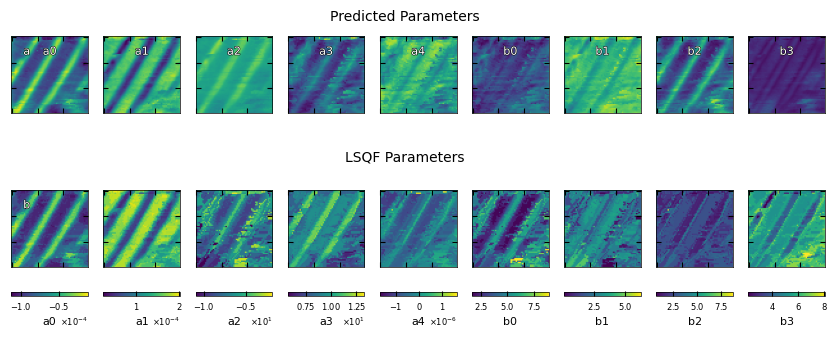

In [28]:
data, voltage = dataset.get_hysteresis(scaled=True, loop_interpolated = True)
data = torch.atleast_3d(torch.tensor(data.reshape(-1, 96)))

pred_recon, pred_params_scaled, pred_params = model.predict(
    data,
    1024,
    translate_params=False,
    is_SHO=False
)
# ran after  only 15 epochs of training on Jan 31 
fig = BE_viz.hysteresis_maps(pred_params, cycle=0, filename="Figure_XX_NN_Hysteresis_Maps")

No spectroscopic datasets found as attributes of /Measurement_000/Channel_000/Position_Indices
No position datasets found as attributes of /Measurement_000/Raw_Data-SHO_Fit_000/Spectroscopic_Values
./Figures/Figure_XX_Violin_test.png
./Figures/Figure_XX_Violin_test.svg


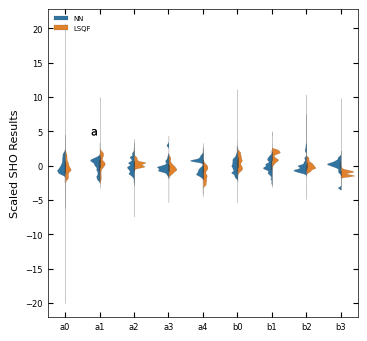

In [17]:
data, voltage = dataset.get_hysteresis(scaled=True, loop_interpolated = True)

fig = BE_viz.violin_plot_comparison_hysteresis(model,
                                         torch.atleast_3d(torch.tensor(data.reshape(-1, 96))),
                                         filename="Figure_XX_Violin_test") 

No spectroscopic datasets found as attributes of /Measurement_000/Channel_000/Position_Indices
No position datasets found as attributes of /Measurement_000/Raw_Data-SHO_Fit_000/Spectroscopic_Values
No spectroscopic datasets found as attributes of /Measurement_000/Channel_000/Position_Indices
No position datasets found as attributes of /Measurement_000/Raw_Data-SHO_Fit_000/Spectroscopic_Values


/home/julian/BEPiezo-Learn/src/belearn/viz/viz.py:3887: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_example['Original Index'] = int(best_example['Original Index'])
/home/julian/BEPiezo-Learn/src/belearn/viz/viz.py:3890: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  worst_example['Original Index'] = int(worst_example['Original Index'])
/home/julian/BEPiezo-Learn/src/belearn/viz/viz.py:3893: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-

./Figures/Figure_XX_LSQF_NN_bmw_comparison_loaded_weights_15_epochs.png
./Figures/Figure_XX_LSQF_NN_bmw_comparison_loaded_weights_15_epochs.svg


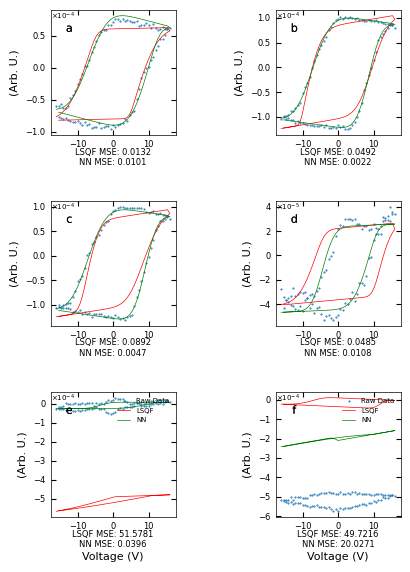

In [29]:
n = 1

# JGODDY: cannot redefine data because it must be from dataset.get_hysteresis so just put this data tuple directly into 
# BE_viz.hysteresis_comparison without predefining it 
 
#data = ("LSQF", "NN") 

fig = BE_viz.hysteresis_comparison(
    ("LSQF", "NN"),
    nn_model=model,
    filename="Figure_XX_LSQF_NN_bmw_comparison_loaded_weights_15_epochs",
)

In [30]:
axes=fig.axes

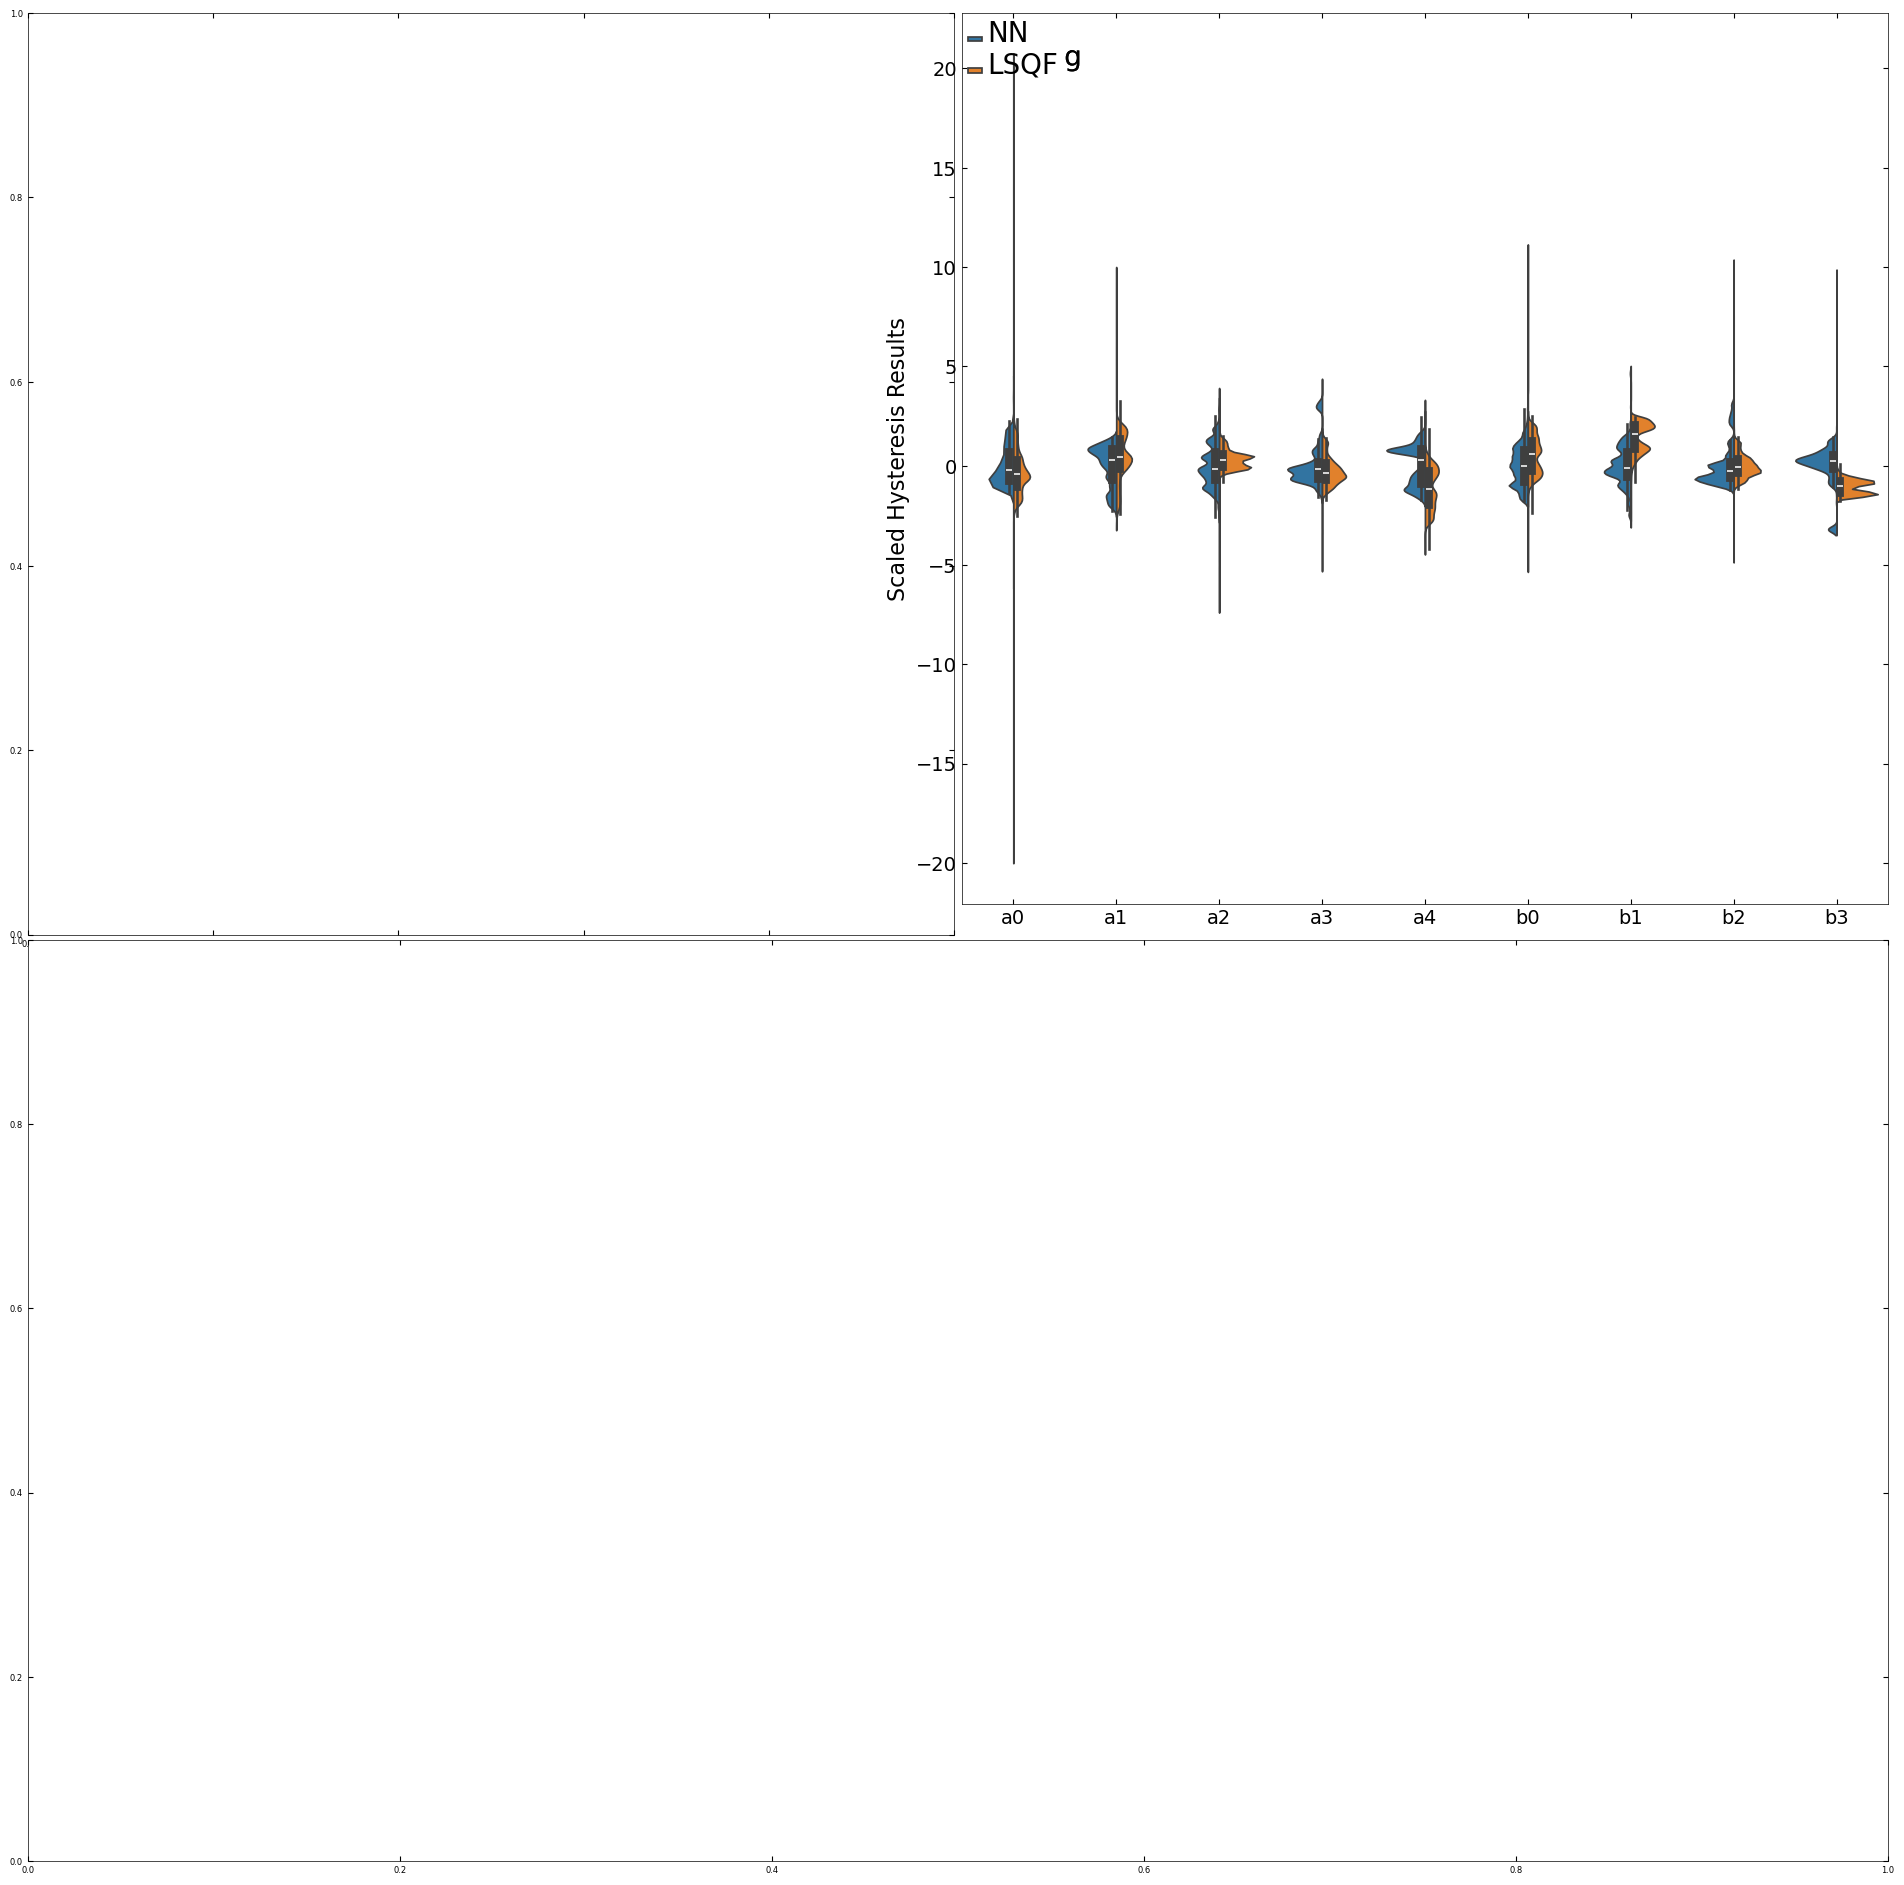

In [47]:
import pandas as pd
import seaborn as sns
import itertools
from torch import nn


from m3util.viz.layout import imagemap, FigDimConverter, subfigures
from m3util.viz.text import number_to_letters, set_sci_notation_label, labelfigs, bring_text_to_front

from matplotlib.ticker import ScalarFormatter
#from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import EngFormatter
#from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec





def y_formatter(y, pos):
    return f"{y * 1e3:.1f}"  # Multiply by 1e3 to show scaled values

def copy_axes_properties(row,col,source_ax, target_ax, secondary_ax, ax_lims):
    """Copy properties and data from source_ax to target_ax."""
    # Copy basic properties
    #target_ax.set_xlabel(source_ax.get_xlabel())
    # uncomment out below 
    target_ax.set_xlim([-20,20])

    if row == 2: # if i in [4,5]:
        target_ax.set_xlabel('Frequency (MHz)',fontsize=20)
    else:
        target_ax.set_xlabel("")
        #target_ax.set_xticks([])
        target_ax.xaxis.set_ticklabels([])

   #target_ax.set_ylim(ax_lims.get_ylim() if max(ax_lims.get_ylim()) > max(source_ax.get_ylim()) else source_ax.get_ylim())

    if col == 0:    
        #target_ax.set_ylim(source_ax.get_ylim())
        target_ax.set_ylabel(source_ax.get_ylabel(),fontsize=20)
    else:
        #target_ax.set_ylim(ax_lims.get_ylim() if max(ax_lims.get_ylim()) > max(source_ax.get_ylim()) else source_ax.get_ylim())
        target_ax.set_ylabel("")
        target_ax.yaxis.set_ticklabels([])

        
    # if row == 0:
    #     target_ax.set_ylim([-0.5e-3,8.0e-3])
    # elif row == 1: 
    #     target_ax.set_ylim([-0.1e-2,2.1e-2])
    # elif row == 2: 
    #     target_ax.set_ylim([-0.1e-2,2.1e-2])    
    
    #target_ax.set_ylim(source_ax.get_ylim())
    target_ax.set_title(source_ax.get_title())

    # Copy lines from the primary axis
    for line in source_ax.get_lines():
        label = line.get_label() if line.get_label() != '_nolegend_' else None
        # Copying line properties like color, linestyle, marker, etc.
        target_ax.plot(line.get_xdata()/1e6, line.get_ydata(), color=line.get_color(),
                       linestyle=line.get_linestyle(), marker=line.get_marker(), label=label)
        
    # Handle twin axes if present
    #if secondary_ax:
    ax_twin = target_ax.twinx()
    ax_twin.set_ylim(secondary_ax.get_ylim())
    #ax_twin.set_yticks([-np.pi,0,np.pi],labels =["$-\pi$","0","$\pi$"])

    if col == 0: #if i % 2 == 0: 
        ax_twin.set_ylabel("")
        ax_twin.yaxis.set_ticklabels([])

        # ax_twin.set_yticks([])
        
        set_sci_notation_label(
                target_ax, corner="top left", axis="y", stroke_color="w", linewidth=0.5,
                textsize = 10, offset_points = (0,30)
            )
    else:
        #target_ax.set_ylabel("")
        ax_twin.set_ylabel(secondary_ax.get_ylabel(),fontsize = 20)
        ax_twin.set_yticks([-3,-2,-1,0,1,2,3])

    
    #ax_twin.set_ylabel(secondary_ax.get_ylabel(),fontsize = 25)


    for line in secondary_ax.get_lines():
        label = line.get_label() if line.get_label() != '_nolegend_' else None
        # Copying line properties for the twin axis
        ax_twin.plot(line.get_xdata()/1e6, line.get_ydata(), color=line.get_color(),
                        linestyle=line.get_linestyle(), marker=line.get_marker(), label=label)

    # # Copy legends
    # if source_ax.get_legend():
    #     target_ax.legend(fontsize='large')

    # if secondary_ax and secondary_ax.get_legend():
    #     ax_twin.legend(fontsize='large')
        
    
    
    #target_ax.set_xlim(min(line.get_xdata())/1e6,max(line.get_xdata())/1e6)
    target_ax.tick_params(axis='x',labelsize=20)
    target_ax.tick_params(axis='y',labelsize=20)
    #target_ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    if row == 0 and col == 0: 
        target_ax.yaxis.set_major_formatter(FuncFormatter(y_formatter))



    #ax_twin.tick_params(axis='x',labelsize=15,length = 10, width = 2)
    ax_twin.tick_params(axis='x',labelsize=20)

    ax_twin.tick_params(axis='y',labelsize=20)
    
    plt.tight_layout()

# Create a figure

fig = plt.figure(figsize=(24, 24))


# Define the GridSpec layout
gs = GridSpec(60, 40, figure=fig)


order = [['NN_fit_comp'],
         ['violin'],
         ['switching_maps']
        ]

subplot_specs = [(0, 30, 0, 20 ), # top left: NN fit comparisons 
                 (0, 29, 20, 40), # g
                 (30, 80, 0, 60), #bottom 
                ]


renderViolin = True
renderSwitchingMaps = False
renderBMWComp = False

for i, (r_start, r_end, c_start, c_end) in enumerate(subplot_specs):
    ax = fig.add_subplot(gs[r_start:r_end, c_start:c_end])
    if i < len(axes):
        idx = order[i]
        if idx[0] == 'violin':
            if renderViolin:
                df = pd.DataFrame()

                # uses the model to get the predictions
                pred_data, scaled_param, params = model.predict(data, is_SHO=False)

                true = dataset.LSQF_hysteresis_params().reshape(-1, 9)

                true_scaled = dataset.loop_param_scaler.transform(true)

                # Builds the dataframe for the violin plot
                true_df = pd.DataFrame(
                    true, columns=["a0", "a1", "a2", "a3", "a4",
                                "b0", "b1", "b2", "b3"]
                )
                predicted_df = pd.DataFrame(
                    scaled_param, columns=["a0", "a1", "a2", "a3", "a4",
                                        "b0", "b1", "b2", "b3"]
                )

                # merges the two dataframes
                df = pd.concat((predicted_df, true_df))

                # adds the labels to the dataframe
                names = [true_scaled, scaled_param]
                names_str = ["NN", "LSQF"]
                labels = ["a0", "a1", "a2", "a3", "a4", "b0", "b1", "b2", "b3"]

                # adds the labels to the dataframe
                for j, name in enumerate(names):
                    for i, label in enumerate(labels):
                        dict_ = {
                            "value": name[:, i],
                            "parameter": np.repeat(label, name.shape[0]),
                            "dataset": np.repeat(names_str[j], name.shape[0]),
                        }

                        df = pd.concat((df, pd.DataFrame(dict_)))
                        
                
                        

    #             # builds the plot
    #             fig, ax = plt.subplots(figsize=(4, 4))

                # Reset index to handle potential duplicated columns or indices
                df = df.reset_index(drop=False)
                
                # plots the data
                sns.violinplot(
                    data=df, x="parameter", y="value", hue="dataset", split=True, ax=ax
                )

                # labels the figure and does some styling
                labelfigs(ax, string_add = 'g', loc ='tl',size=20, style="b", inset_fraction=(0.05,0.12))
                ax.set_ylabel("Scaled Hysteresis Results",fontsize=16)
                ax.set_xlabel("")
                
                ax.tick_params(axis='x',labelsize=14)
                ax.tick_params(axis='y',labelsize=14)

                # Get the legend associated with the plot
                legend = ax.get_legend()
                legend.set_title("")
                plt.setp(legend.get_texts(), fontsize=20) # Set the label size
        
        elif idx[0] == "switching_maps": 
            if renderSwitchingMaps:
                colorbars=True,
                cycle=0,
                fig_width=10.5,  # figure width in inches
                filename=None,

                # # reshape data:
                # if data.shape != 3:
                
                pred_recon, pred_params_scaled, pred_params = model.predict(
                    data,
                    1024,
                    translate_params=False,
                    is_SHO=False
                )

                # calculates the size of the embedding image
                embedding_image_size = 60

                fig, axs = plt.subplots(
                    2,
                    9,
                    figsize=(fig_width, 4),
                    gridspec_kw={"height_ratios": [1, 1]},
                )

                parms_lsqf = dataset.LSQF_hysteresis_params()[:, :, cycle, :].reshape(-1, 9)
                pred_params = pred_params.reshape(embedding_image_size, embedding_image_size, 4, 9)[:, :, cycle, :].reshape(-1, 9)

                clims = []

                colorbar_labels = [
                    'a0', 'a1', 'a2', 'a3', 'a4', 'b0', 'b1', 'b2', 'b3'
                ]

                # Titles for each row
                row_titles = ['Predicted Parameters', 'LSQF Parameters']

                string_add = 'a'

                for i in range(9):
                    clims.append(
                        (
                            np.min(
                                [
                                    pred_params[:, i].min(),
                                    parms_lsqf[:, i].min(),
                                ]
                            ),
                            np.max(
                                [
                                    pred_params[:, i].max(),
                                    parms_lsqf[:, i].max(),
                                ]
                            ),
                        )
                    )

                    axs[0, i].imshow(
                        pred_params[:, i].reshape(
                            embedding_image_size, embedding_image_size),
                        cmap="viridis",
                        vmin=clims[i][0],
                        vmax=clims[i][1],
                    )
                    axs[0,i].set_xticklabels('')
                    axs[0,i].set_yticklabels('')
                    axs[1, i].imshow(
                        parms_lsqf[:, i].reshape(
                            embedding_image_size, embedding_image_size),
                        cmap="viridis",
                        vmin=clims[i][0],
                        vmax=clims[i][1],
                    )
                    axs[1,i].set_xticklabels('')
                    axs[1,i].set_yticklabels('')

                    if colorbars:
                        
                        # Create an axis divider for each subplot
                        divider = make_axes_locatable(axs[1, i])
                        # Append axes to the bottom of the divider with appropriate padding
                        cax = divider.append_axes("bottom", size="5%", pad=0.25) 
                        
                        
                        fmt = ScalarFormatter(useMathText=True)
                        fmt.set_powerlimits((0, 0))
                        cbar = plt.colorbar(axs[1,i].images[0],
                                            cax=cax, format=fmt,orientation = 'horizontal')
                        cbar.set_label(colorbar_labels[i])  # Add a label to the colorbar

                        
                        
                        # cbar = plt.colorbar(
                        #     axs[1, i].images[0], cax=cax, format="%.1e", orientation='horizontal')
                        # # Set the label for each colorbar
                        # cbar.set_label(colorbar_labels[i])

                    labelfigs(axs[0,i],
                            string_add=colorbar_labels[i],
                            loc ='ct',
                            size=8,
                            inset_fraction=(0.2, 0.2)
                            )
                        # Update the char to the next order
                    ascii_value = ord(string_add)+1
                    string_add = chr(ascii_value)

                labelfigs(axs[0,0],
                string_add='a',
                loc ='tl',
                size=8,
                inset_fraction=(0.2, 0.2)
                )
                labelfigs(axs[1,0],
                string_add='b',
                loc ='tl',
                size=8,
                inset_fraction=(0.2, 0.2)
                )

                # Calculate the vertical position for the row titles
                title_y_positions = [0.85, 0.5]  # You may need to adjust these values

                # Set the titles for each row using fig.text
                for i, title in enumerate(row_titles):
                    fig.text(0.5, title_y_positions[i], title, ha='center',
                                va='center', fontsize=10, transform=fig.transFigure)


                # # prints the figure
                # if self.Printer is not None and filename is not None:
                #     print('use printing function')
                #     self.Printer.savefig(
                #         fig, filename, size=6, loc="tl", inset_fraction=(0.2, 0.2)
                #     )
                
                ax.add_child_axes(axs)
                # for row in range(2):
                #     for col in range(9):
                #         inset_ax = ax.inset_axes([-0.06+(col/11.8)+np.floor(col/4)/256,1-(row+1)/6.1-row/192-np.floor(row/2)/96,1/6.1,1/6.1])
                #         inset_ax.imshow(axs[(9*row)+col].get_images()[0].get_array().data)
                        
                # ax.axis("off")


In [48]:
axs

array([[<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >]], dtype=object)